<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/daylichallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Comprendre les types de classification

### Classification binaire
- **Définition** : Prédire une étiquette parmi deux classes mutuellement exclusives.
- **Exemple** : Détection de spam (spam / non‑spam).

### Classification multi‑classe
- **Définition** : Prédire une étiquette parmi plusieurs classes (plus de deux), chaque échantillon appartenant à une seule classe.
- **Exemple** : Reconnaissance de chiffres manuscrits (0 à 9).

### Classification multi‑label
- **Définition** : Prédire un ensemble d’étiquettes pour un même échantillon (les classes ne sont pas exclusives).
- **Exemple** : Annotation d’images (une image peut contenir un chat, un chien et une voiture).

###make_circles

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

y :  [1 1 1 1 0]


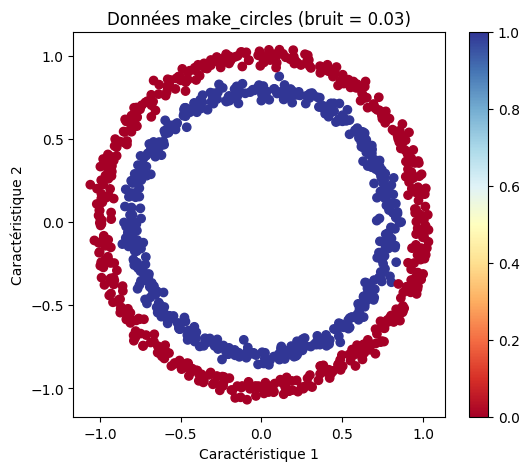

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Génération des données
samples = 1000
X, y = make_circles(samples,
                    noise=0.03,
                    random_state=42)

print('X : ', X[:5])
print('\ny : ', y[:5])

# Visualisation du jeu de données
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Données make_circles (bruit = 0.03)")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.colorbar()
plt.show()

###Modèle de base

In [9]:
# Modèle basique
model_basic = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

model_basic.compile(loss='binary_crossentropy',
                    optimizer=tf.keras.optimizers.SGD(),
                    metrics=['accuracy'])

history_basic = model_basic.fit(X, y, epochs=100, verbose=0)

# Évaluation
loss_basic, acc_basic = model_basic.evaluate(X, y, verbose=0)
print(f"Modèle basique - Précision : {acc_basic:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modèle basique - Précision : 0.5080


###Amélioration du modèle (couches supplémentaires, neurones, Adam, plus d’epochs)

In [3]:
# Modèle amélioré
model_improved = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_improved.compile(loss='binary_crossentropy',
                       optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                       metrics=['accuracy'])

history_improved = model_improved.fit(X, y, epochs=200, verbose=0)

loss_imp, acc_imp = model_improved.evaluate(X, y, verbose=0)
print(f"Modèle amélioré - Précision : {acc_imp:.4f}")

Modèle amélioré - Précision : 1.0000


### Visualisation de la frontière de décision (fonction générique)


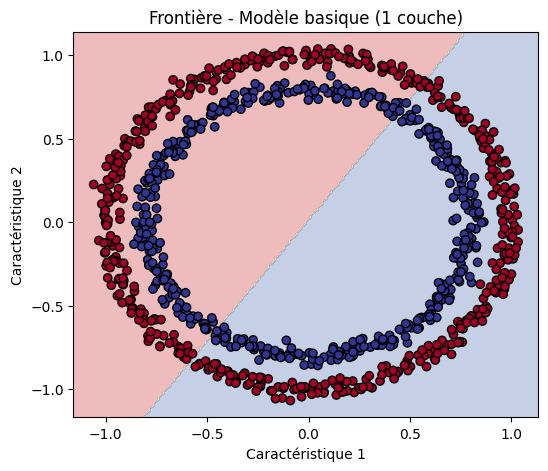

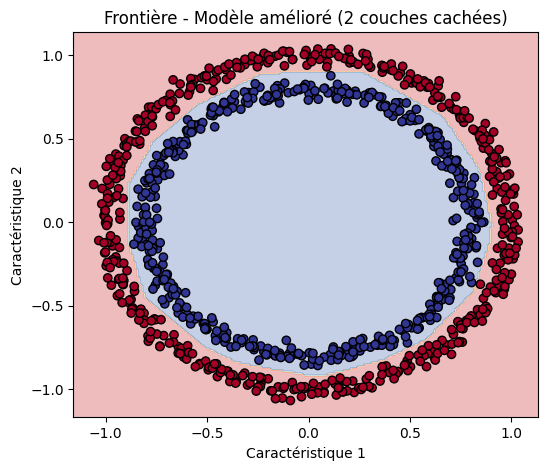

In [4]:
def plot_decision_boundary(model, X, y, title="Frontière de décision"):
    """
    Trace la frontière de décision d'un modèle sur l'ensemble X.
    """
    # Définition de la grille
    x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
    y_min, y_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Prédictions sur la grille
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title(title)
    plt.xlabel("Caractéristique 1")
    plt.ylabel("Caractéristique 2")
    plt.show()

# Tracer les frontières des deux modèles
plot_decision_boundary(model_basic, X, y, title="Frontière - Modèle basique (1 couche)")
plot_decision_boundary(model_improved, X, y, title="Frontière - Modèle amélioré (2 couches cachées)")

###Incorporation de fonctions d'activation (ReLU, Sigmoid) – comparaison

Modèle avec sigmoid caché - Précision : 0.5560
Modèle avec ReLU - Précision : 1.0000


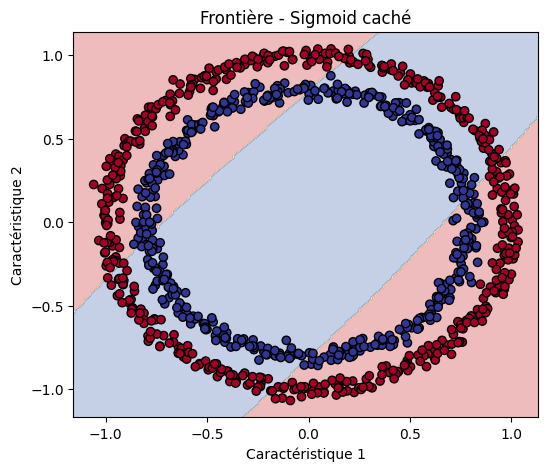

In [5]:
# Modèle avec activation sigmoid dans les couches cachées
model_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='sigmoid', input_shape=(2,)),
    tf.keras.layers.Dense(10, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_sigmoid.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
model_sigmoid.fit(X, y, epochs=200, verbose=0)
loss_sig, acc_sig = model_sigmoid.evaluate(X, y, verbose=0)
print(f"Modèle avec sigmoid caché - Précision : {acc_sig:.4f}")

# Modèle avec ReLU (déjà fait dans l'amélioré) – on réutilise model_improved
# On compare les deux
print(f"Modèle avec ReLU - Précision : {acc_imp:.4f}")

# Visualisation de la frontière du modèle sigmoid
plot_decision_boundary(model_sigmoid, X, y, title="Frontière - Sigmoid caché")

Modèle avec sigmoid caché - Précision : 0.6290
Modèle avec ReLU - Précision : 1.0000


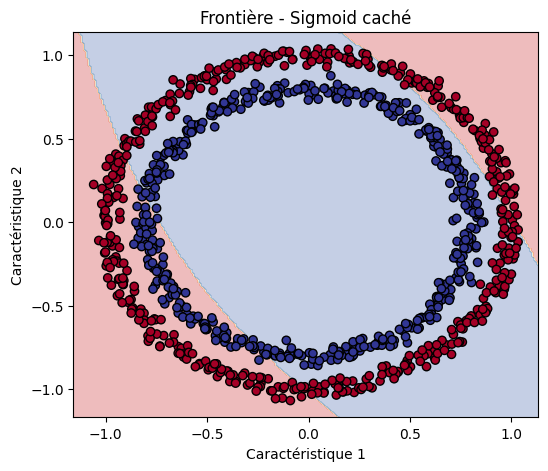

In [6]:
# Modèle avec activation sigmoid dans les couches cachées
model_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='sigmoid', input_shape=(2,)),
    tf.keras.layers.Dense(10, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_sigmoid.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])
model_sigmoid.fit(X, y, epochs=200, verbose=0)
loss_sig, acc_sig = model_sigmoid.evaluate(X, y, verbose=0)
print(f"Modèle avec sigmoid caché - Précision : {acc_sig:.4f}")

# Modèle avec ReLU (déjà fait dans l'amélioré) – on réutilise model_improved
# On compare les deux
print(f"Modèle avec ReLU - Précision : {acc_imp:.4f}")

# Visualisation de la frontière du modèle sigmoid
plot_decision_boundary(model_sigmoid, X, y, title="Frontière - Sigmoid caché")

###Séparation en entraînement (80%) et test (20%)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ré-entraîner le modèle amélioré sur l'ensemble d'entraînement
model_final = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_final.compile(loss='binary_crossentropy',
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    metrics=['accuracy'])
model_final.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluation sur l'ensemble de test
loss_test, acc_test = model_final.evaluate(X_test, y_test, verbose=0)
print(f"Modèle final - Précision sur le test : {acc_test:.4f}")

Modèle final - Précision sur le test : 1.0000


###Évaluation et visualisation finales

Précision sur l'entraînement : 1.0000
Précision sur le test       : 1.0000


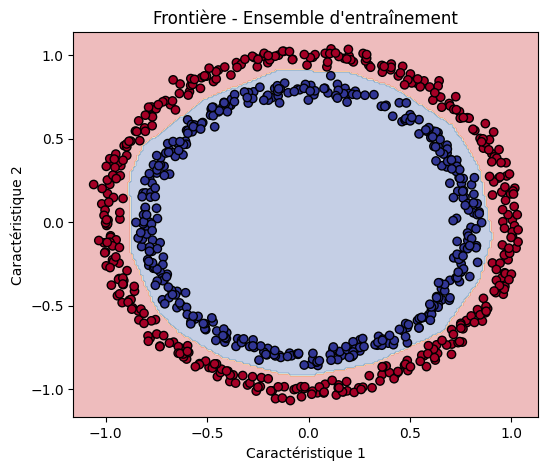

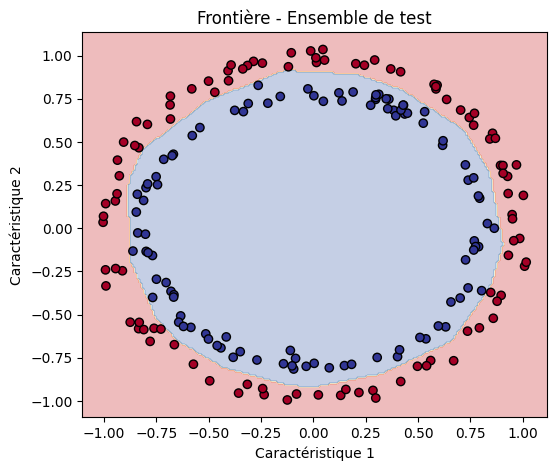

In [8]:
# Prédictions sur l'ensemble d'entraînement et de test
y_pred_train = (model_final.predict(X_train, verbose=0) > 0.5).astype(int)
y_pred_test  = (model_final.predict(X_test, verbose=0) > 0.5).astype(int)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)

print(f"Précision sur l'entraînement : {acc_train:.4f}")
print(f"Précision sur le test       : {acc_test:.4f}")

# Frontières de décision pour les deux ensembles
plot_decision_boundary(model_final, X_train, y_train, title="Frontière - Ensemble d'entraînement")
plot_decision_boundary(model_final, X_test, y_test, title="Frontière - Ensemble de test")

##Résumé des apprentissages
### Points clés retenus
- La **visualisation des données** est essentielle pour comprendre la distribution et choisir un modèle adapté.
- L’ajout de **couches cachées et de neurones** permet au réseau d’apprendre des frontières non linéaires.
- Le choix de la **fonction d’activation** (ReLU vs sigmoid) influence la convergence et la capacité à capturer des motifs complexes.
- L’**optimiseur Adam** accélère l’apprentissage par rapport à SGD.
- L’**évaluation sur un ensemble de test** permet de mesurer la généralisation du modèle.
- L’**ajustement des hyperparamètres** (nombre de couches, neurones, epochs, taux d’apprentissage) est crucial pour améliorer les performances.